# Masserstein error on the held-out images (axis-200-900)

The three held-out images are reconstructed pixel by pixel and the Masserstein cost is mapped back onto the image, globally and per 100 Da window, together with the mass the input and the reconstruction place in every window. This notebook analyses the *error*; how the reconstructed images *look* channel by channel is the subject of `part_1_05`.

## Introduction

The decoder output is TIC-normalized like its input, so the total mass of every pixel is reproduced by
construction and a TIC image of the reconstruction would equal the input TIC image. What can go wrong is how
the mass of a pixel is distributed along m/z. Maps of the global and windowed costs show where on the tissue
and in which m/z range this happens; images of the input and output mass per window show whether the spatial
pattern of every m/z region is kept.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

        * Maps show the representative model of the axis (next section), never a repetition mean; the SD map shows
          where the five repetitions disagree.
        * Window maps use the displayed windows: windows whose mean held-out TIC fraction is at least 1 %
          (`display.minimum_window_mass_fraction`).
        * The interactive browser uses the stored float16 reconstruction of the representative model on the displayed
          windows; it is not stored in the saved notebook. Static panels of deterministic pixels are stored instead.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

        * $M_W(x) = \sum_{j \in W} X_j(x)$ and $\hat M_W(x)$: input and output mass of window $W$ in pixel $x$
          (fraction of the pixel's TIC); $\Delta_W = \hat M_W - M_W$.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "heldout_image_reconstruction"
AXIS = "axis-200-900"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

maps = table('pixel_maps')
SHOWN_WINDOWS = metadata['displayed_windows']
print('Representative model:', metadata['representative_model'])
print('Displayed windows:', SHOWN_WINDOWS)

Analysis: heldout_image_reconstruction | axis: axis-200-900 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 200-900 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


Representative model: metaspace-pretrain-repaired-20260923-01__grid_0000__rep_02__real_only
Displayed windows: ['200-300', '300-400', '400-500', '500-600', '700-800', '800-900']


## Producing the tables this notebook reads

### Methodology

#### Implementation

Pixel metrics and window arrays come from the `inference` level; `heldout_image_reconstruction` takes the
representative model's values per pixel (and the SD over repetitions), attaches image coordinates, compares
image means with the test mean, measures the agreement of input and output window-mass images and selects the
best, median and worst pixel of every image for static spectrum panels.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis heldout_image_reconstruction > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Representative model shown in the images

### Methodology

#### Theoretical

Images are never averaged over repetitions, because averaging blurs them. Every image shows the
representative model of its axis: the repetition with the lowest mean rank over five metrics on the withheld
test pixels, Masserstein $W_1$ and spectral angle (lower is better), macro AP, micro AP and macro F1 at 0.5
(higher is better; annotation retrieval, classes observed in training); equal mean ranks are decided by macro
AP. The held-out images are not used for the choice, so the displayed model is not selected on the images it
is shown on.

#### Implementation

`representative_model` holds, per model and metric, the test value, its rank among the repetitions of the axis, the mean rank and the flag.

#### Figure descriptions

No figure; one row per model with the metric values, the mean rank and the representative flag.

In [3]:
ranking = table('representative_model')
values = ranking.pivot_table(index=['axis', 'repetition', 'model_id'], columns='metric', values='value')
flags = ranking.groupby(['axis', 'repetition', 'model_id']).agg(mean_rank=('mean_rank', 'first'), representative=('representative', 'first'))
display(values.join(flags).round(4))

average_precision      f1  masserstein  micro_average_precision  spectral_angle  mean_rank  representative
axis         repetition model_id                                                                                                                                                      
axis-200-900 0          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6970  0.4851       3.2834                   0.8835          0.9449        3.0           False
             1          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6899  0.4772       2.9758                   0.8751          1.0732        4.2           False
             2          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6990  0.5055       3.1069                   0.8918          0.9337        1.4            True
             3          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6947  0.4789       3.1123                   0.9003          0.9509        3.2           False
             4          metaspace-pretrain-repaired-20260923-01__grid_0...             0.6957  0.4872       3.1081                   0.8833          0.9554        3.2           False

### Remarks

- Representative model: repetition 2 (mean rank 1.4 of 5): best macro AP (0.699), F1 (0.506) and spectral angle (0.934); repetition 1 has the lowest $W_1$ (2.98) but the worst angle and AP, so no repetition wins every metric.

### Notes

## Whole-image metrics against the test pixels

### Methodology

#### Theoretical

For image $d$ and repetition $r$ the difference $\bar f_{r,d} - \bar f_{r,\mathrm{test}}$ measures how much
worse (or better) the whole new image is reconstructed than withheld pixels of the training images.

#### Implementation

`image_vs_test` holds image means, the test mean and their difference per model, image and metric.

#### Figure descriptions

x = held-out image, y = difference to the test mean; colour = metric, one point per repetition, bar = mean.
Positive values are worse for every metric shown except `cosine_similarity`.

difference                                                     image_mean                                          
dataset_id        2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s 2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s
metric                                                                                                                                         
cosine_similarity               0.0816               0.0707               0.0865               0.6397               0.6288               0.6445
mae                             0.0000               0.0000               0.0000               0.0009               0.0010               0.0010
masserstein                     0.0871               0.0626              -0.3273               3.2044               3.1799               2.7900
mse                             0.0000               0.0000               0.0000               0.0000               0.0000               0.0000
spectral_angle                 -0.1020              -0.0877              -0.1081               0.8696               0.8839               0.8635
tic_error                      -0.0000               0.0000              -0.0000              -0.0000              -0.0000              -0.0000

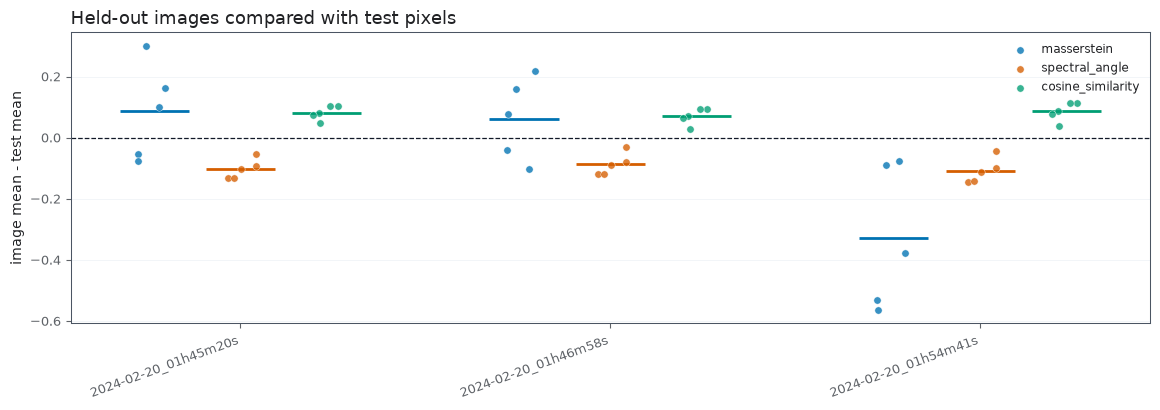

In [4]:
image_vs_test = table('image_vs_test')
display(image_vs_test.pivot_table(index='metric', columns='dataset_id', values=['image_mean', 'difference']).round(4))
shown = image_vs_test[image_vs_test.metric.isin(['masserstein', 'spectral_angle', 'cosine_similarity'])]
figures.repetition_points(shown, value='difference', group='dataset_id', hue='metric', order=DATASETS, hue_order=['masserstein', 'spectral_angle', 'cosine_similarity'], colors={'masserstein': theme.model_palette[0], 'spectral_angle': theme.model_palette[1], 'cosine_similarity': theme.model_palette[2]}, ylabel='image mean - test mean', title='Held-out images compared with test pixels', reference=0.0, theme=theme);

### Remarks

- Cosine higher and spectral angle lower on all three images in every repetition; W1 differences change sign (-0.33 to +0.09).

### Notes

## Maps of the global reconstruction error

### Methodology

#### Theoretical

The spatial distribution of $W_1$ and of the spectral angle, together with the raw input TIC, shows whether
errors follow tissue structure, intensity or the tissue border. The between-repetition SD of $W_1$ shows where
the five models disagree.

#### Implementation

`pixel_maps` holds one row per held-out pixel with the representative model's global metrics and their SD over repetitions.

#### Figure descriptions

Rows = held-out images, columns = input TIC (before normalization), $W_1$, SD of $W_1$ over repetitions, spectral
angle, cosine similarity (representative model). Colour ranges are shared within a column (1st-99th percentile).

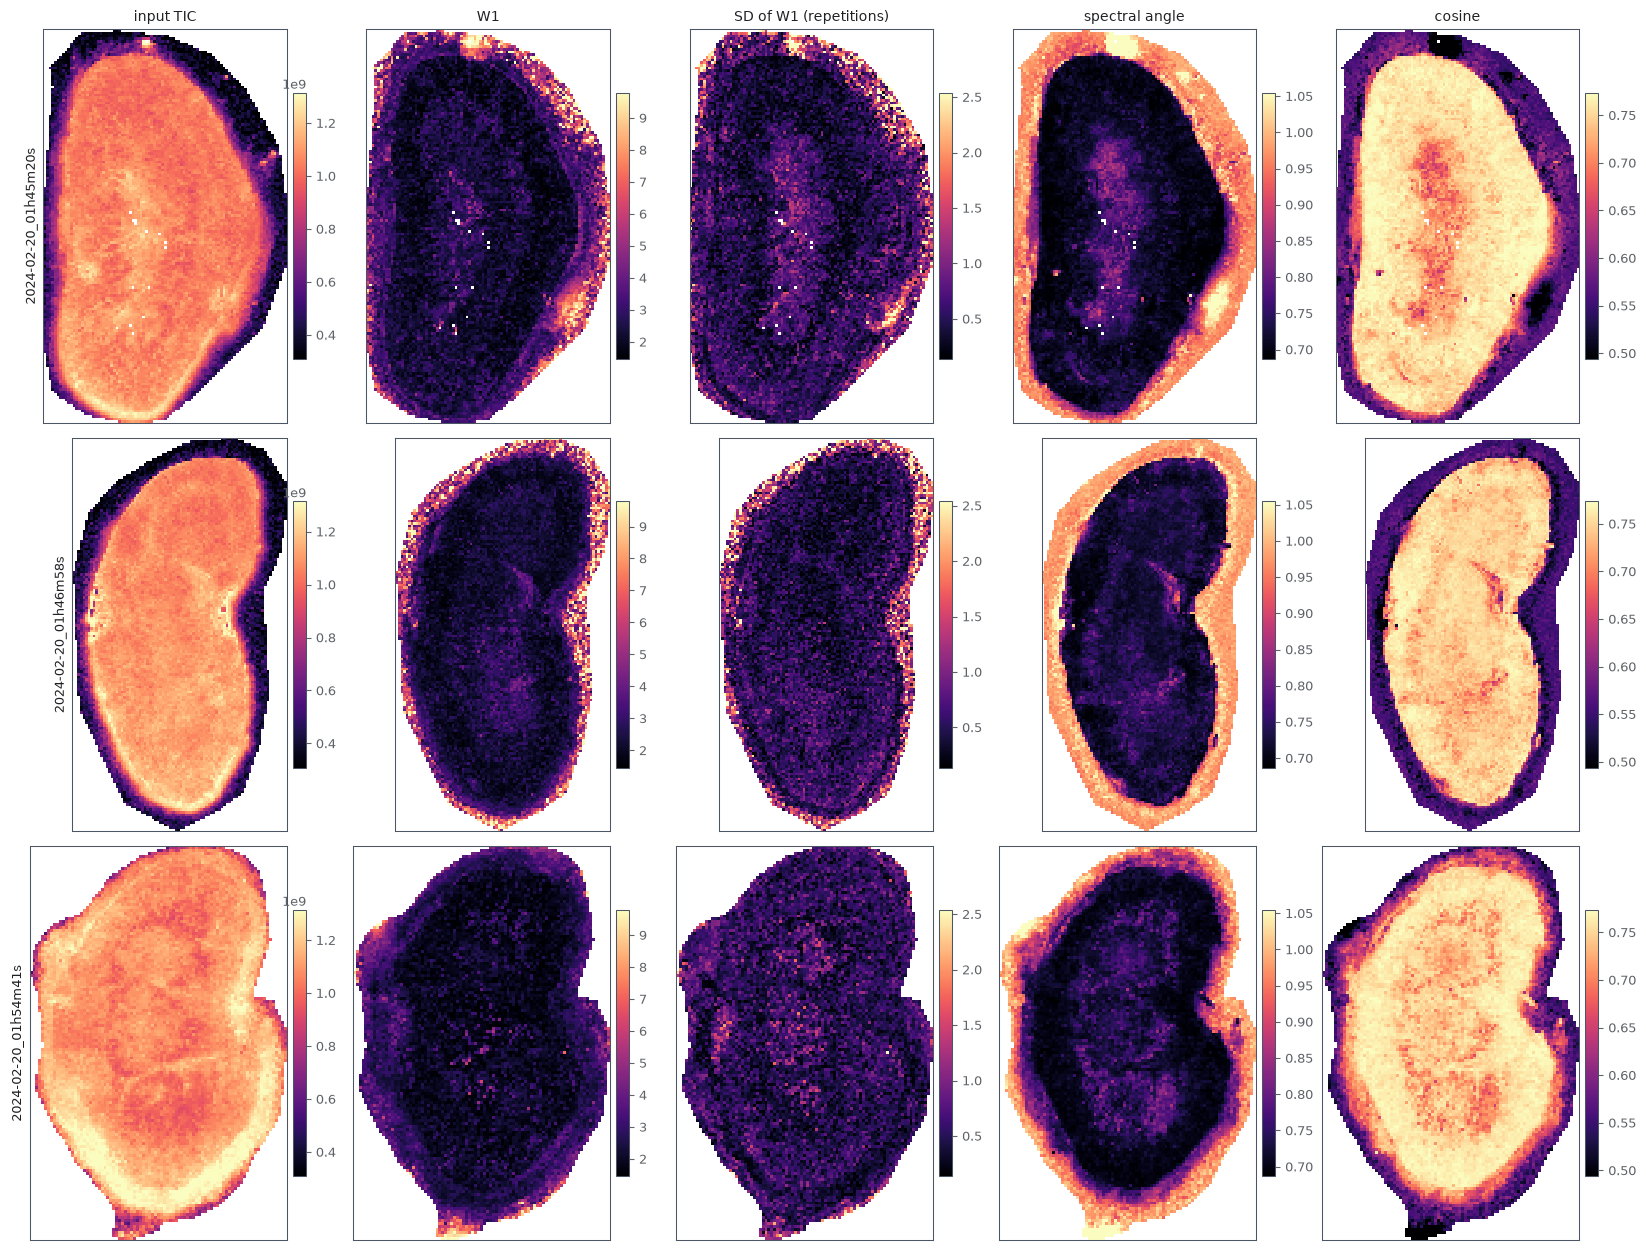

In [5]:
figures.image_panels(maps, value_columns=['input_tic', 'masserstein', 'masserstein_sd', 'spectral_angle', 'cosine_similarity'], column_titles=['input TIC', 'W1', 'SD of W1 (repetitions)', 'spectral angle', 'cosine'], datasets=DATASETS, theme=theme);

### Remarks

- Representative-model $W_1$ per image: 3.06, 3.19, 2.54; `tic_error` is 0 in every pixel (TIC-normalized output).
- The repetition SD of $W_1$ is 0.56-0.67 (about 20 % of $W_1$) and is largest where $W_1$ is largest; high-error pixels lie at the tissue border and in low-intensity regions.

### Notes

## Maps of the local Masserstein decomposition

### Methodology

#### Theoretical

The contribution $C_W$ and the within-window cost $w_W$ per pixel localise the error jointly in space and in
m/z; the signed imbalance $\Delta_W$ shows where the decoder moves intensity into or out of a window.

#### Implementation

Window columns of `pixel_maps` (representative model), restricted to the displayed windows.

#### Figure descriptions

Three figures with rows = held-out images and columns = displayed windows: (1) contribution (m/z), (2)
within-window cost (m/z), (3) signed imbalance (red = reconstruction holds more intensity than the input,
blue = less). Colour ranges are shared within a column.

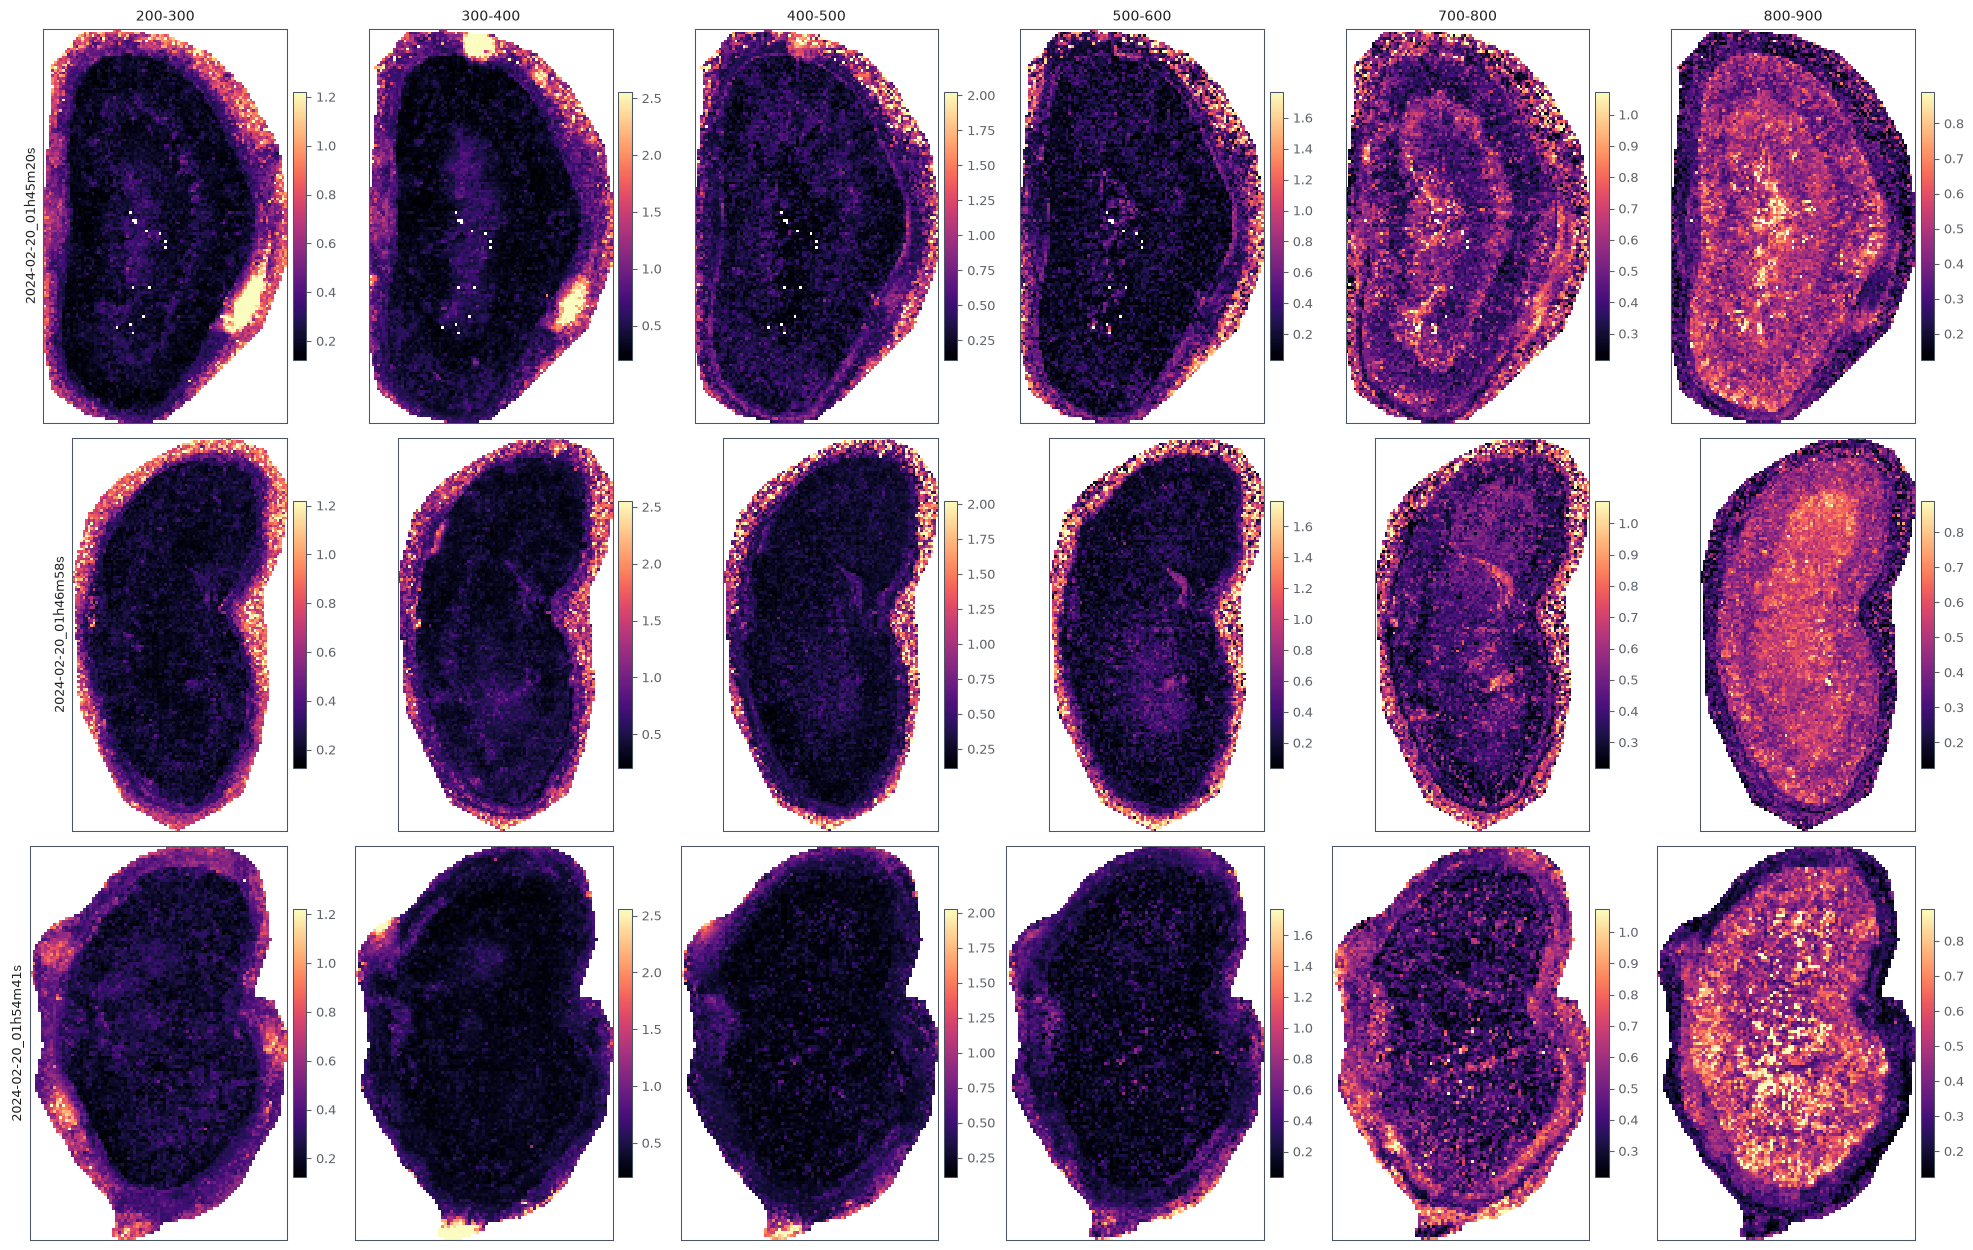

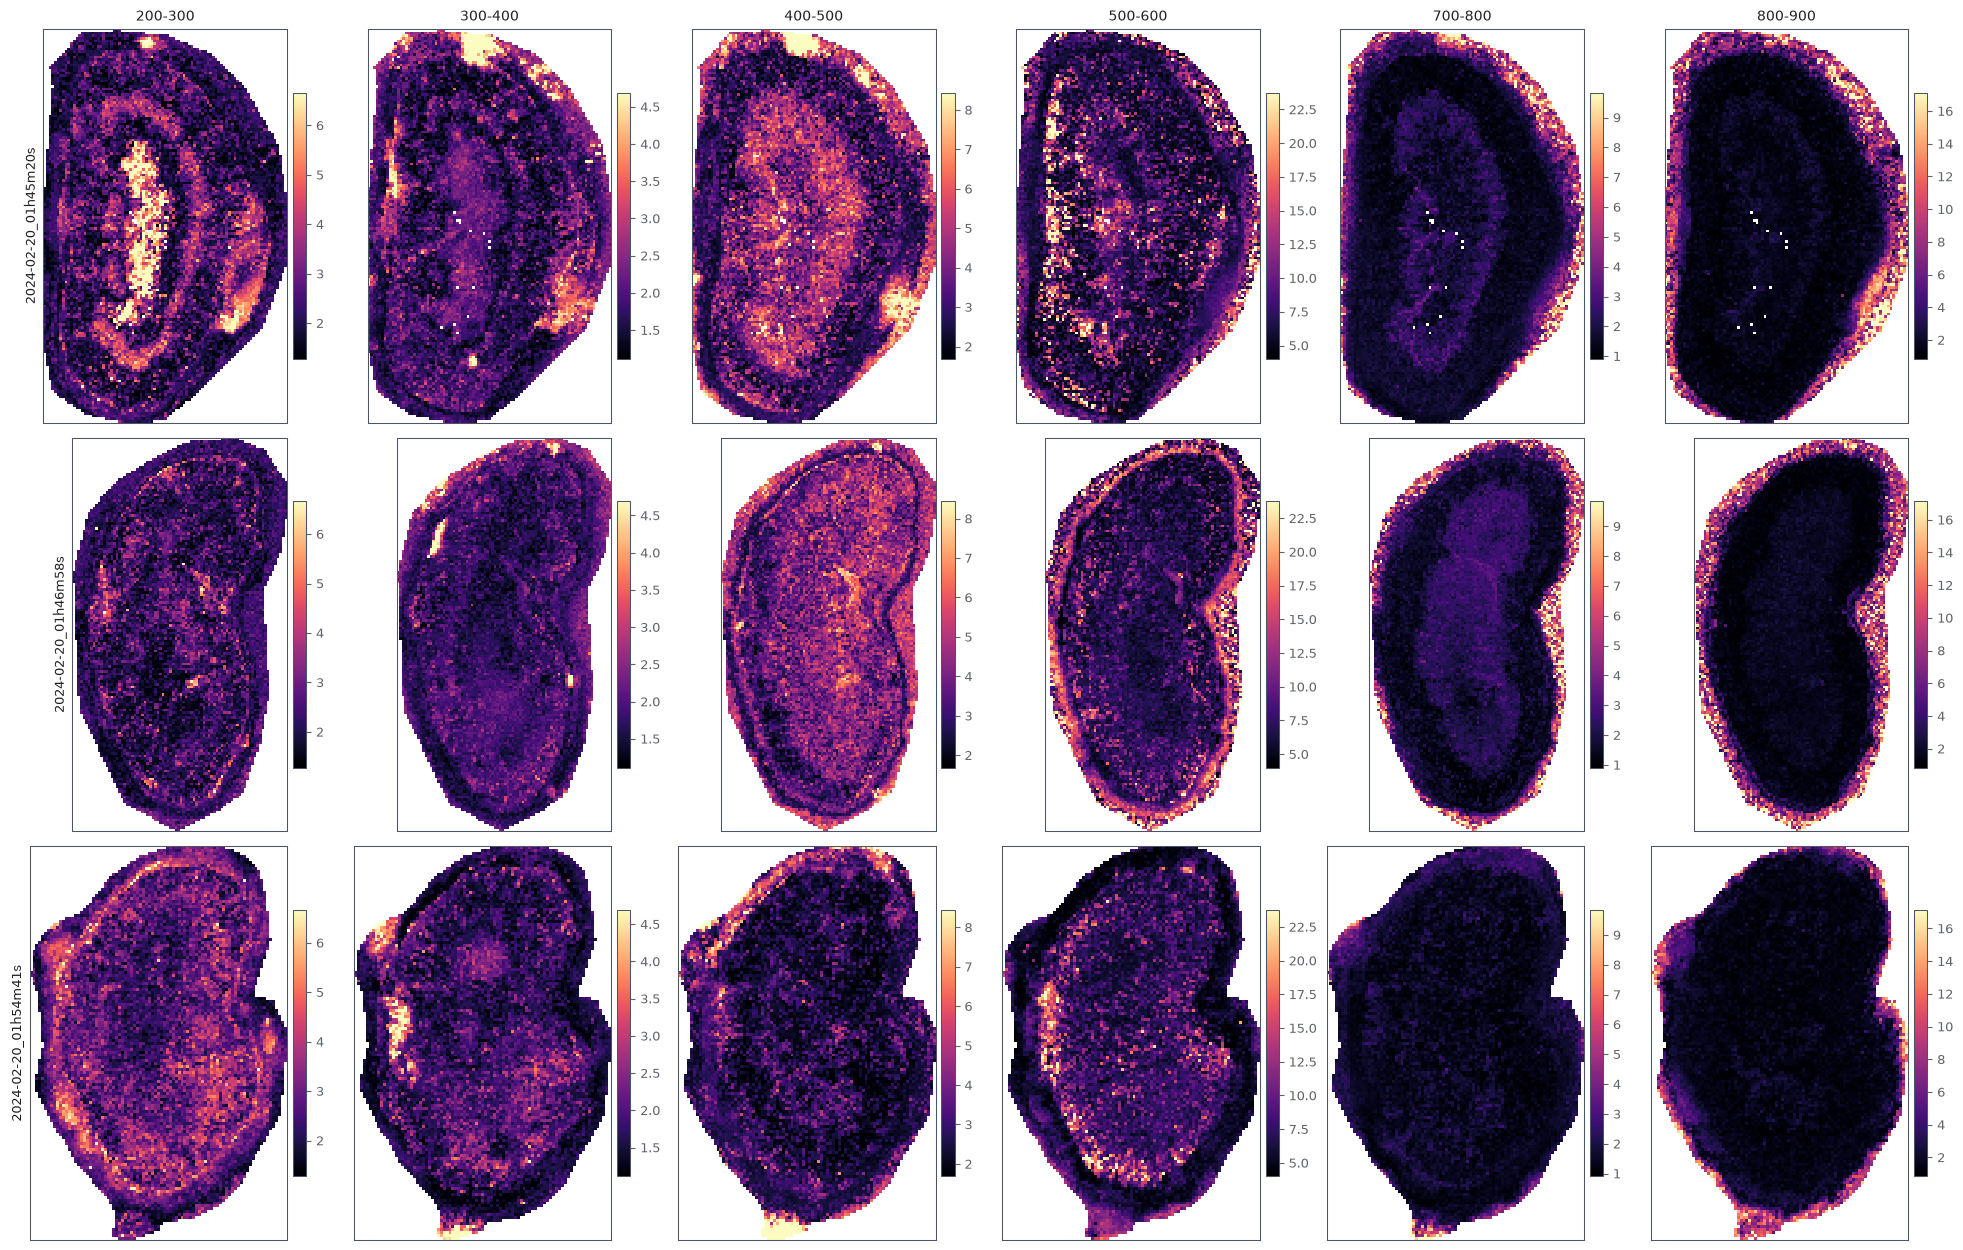

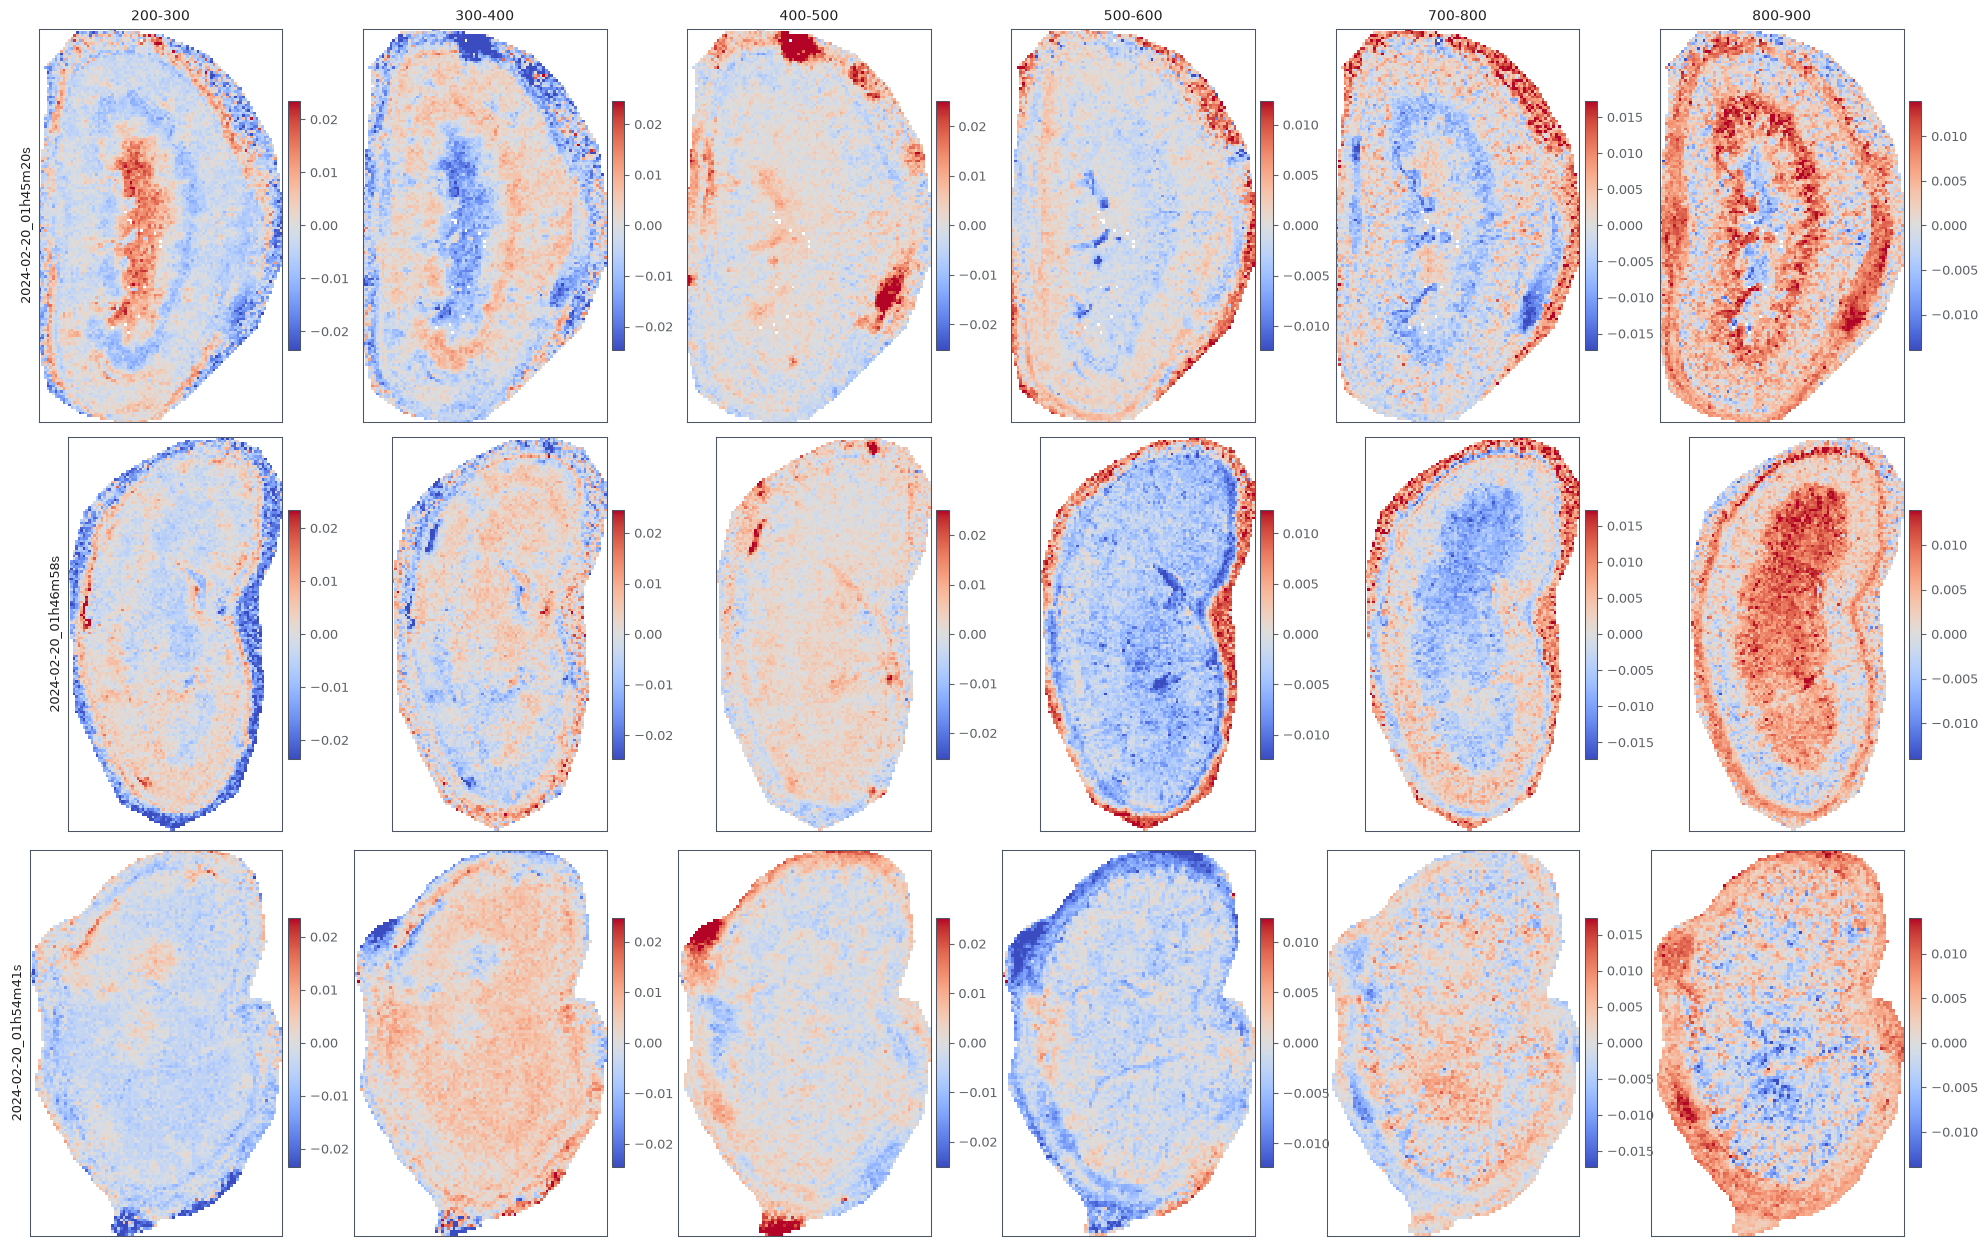

In [6]:
figures.image_panels(maps, value_columns=[f'contribution__{window}' for window in SHOWN_WINDOWS], column_titles=SHOWN_WINDOWS, datasets=DATASETS, theme=theme);
figures.image_panels(maps, value_columns=[f'within__{window}' for window in SHOWN_WINDOWS], column_titles=SHOWN_WINDOWS, datasets=DATASETS, theme=theme);
figures.image_panels(maps, value_columns=[f'mass_imbalance__{window}' for window in SHOWN_WINDOWS], column_titles=SHOWN_WINDOWS, datasets=DATASETS, diverging=True, theme=theme);

### Remarks

- Only windows with at least 1 % of the mean held-out TIC are shown (600-700 m/z is below and not displayed).

### Notes

## Input and output mass of every window as images

### Methodology

#### Theoretical

Since the total mass of a pixel is fixed, the informative whole-image comparison is per m/z region: the image
of $M_W$ against the image of $\hat M_W$. Equal images mean that the decoder keeps the spatial pattern of the
region; a flattened output image means that the decoder assigns every pixel a similar mass regardless of the
input.

#### Implementation

Columns `input_mass__W` and `output_mass__W` of `pixel_maps` (representative model), displayed windows.

#### Figure descriptions

One figure per displayed window; rows = held-out images, columns = input mass, output mass (shared colour range
within a row) and the signed difference output - input (symmetric range).

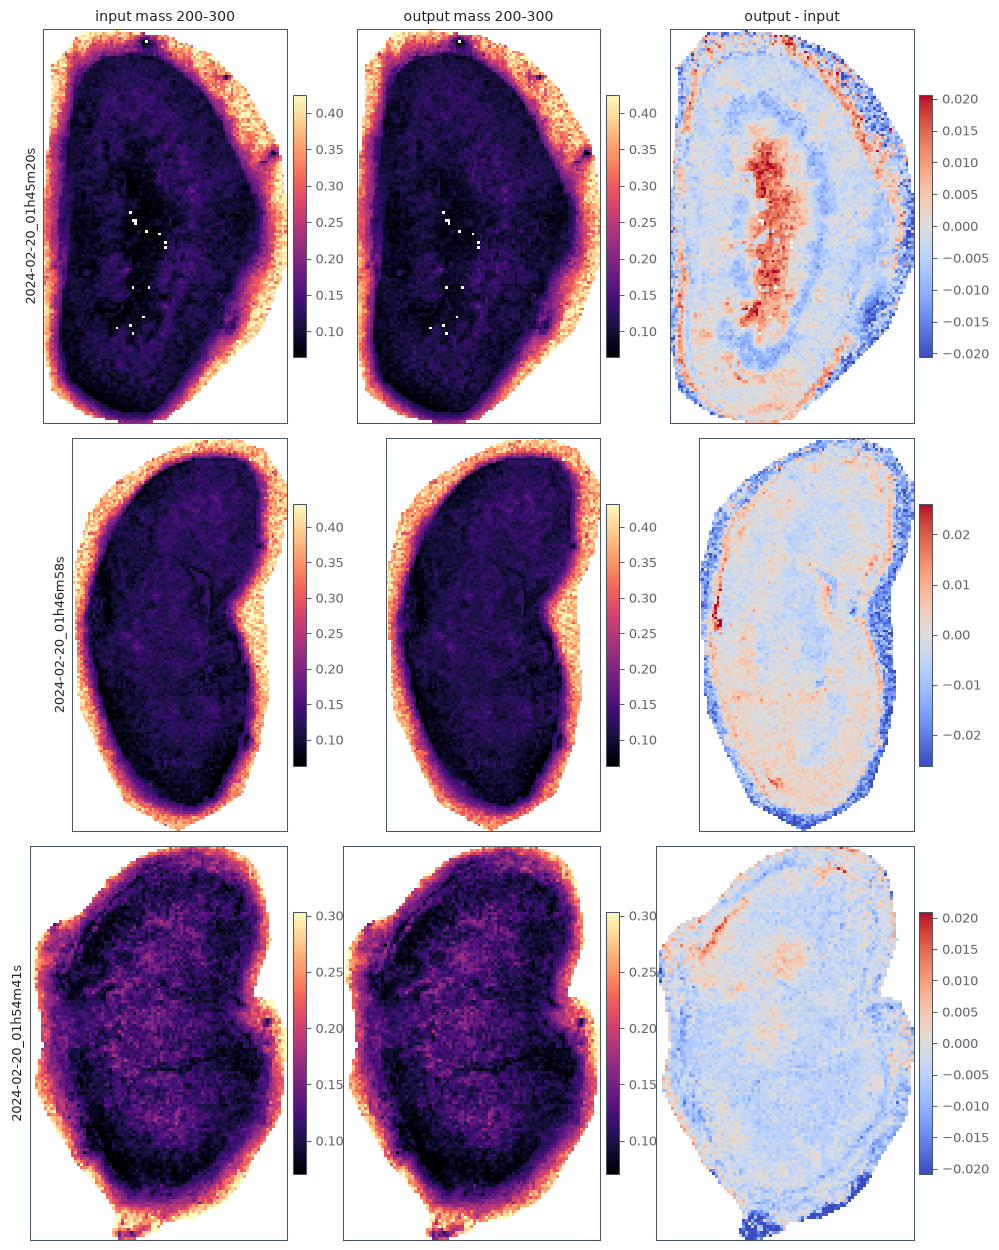

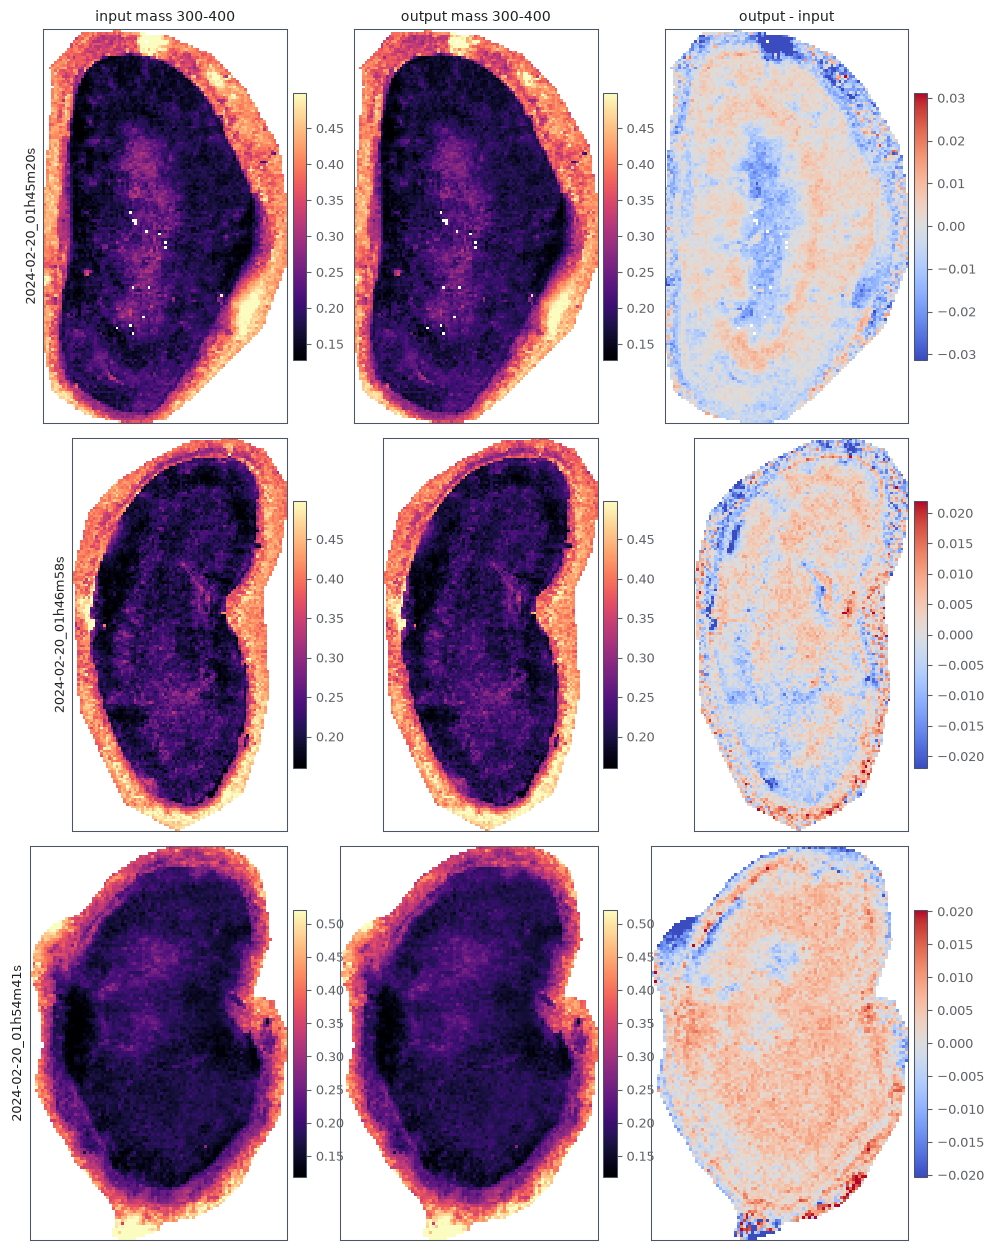

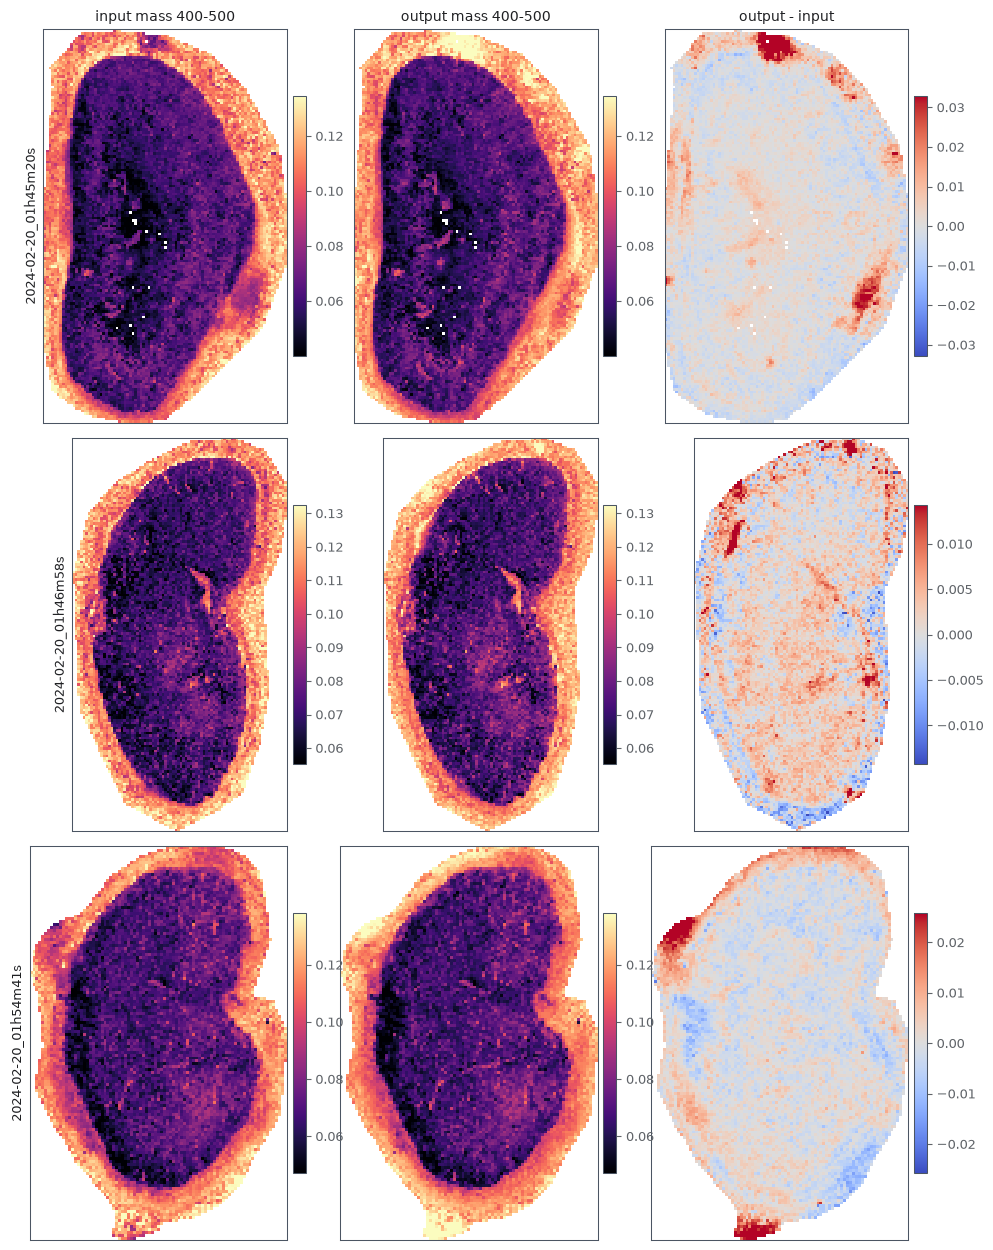

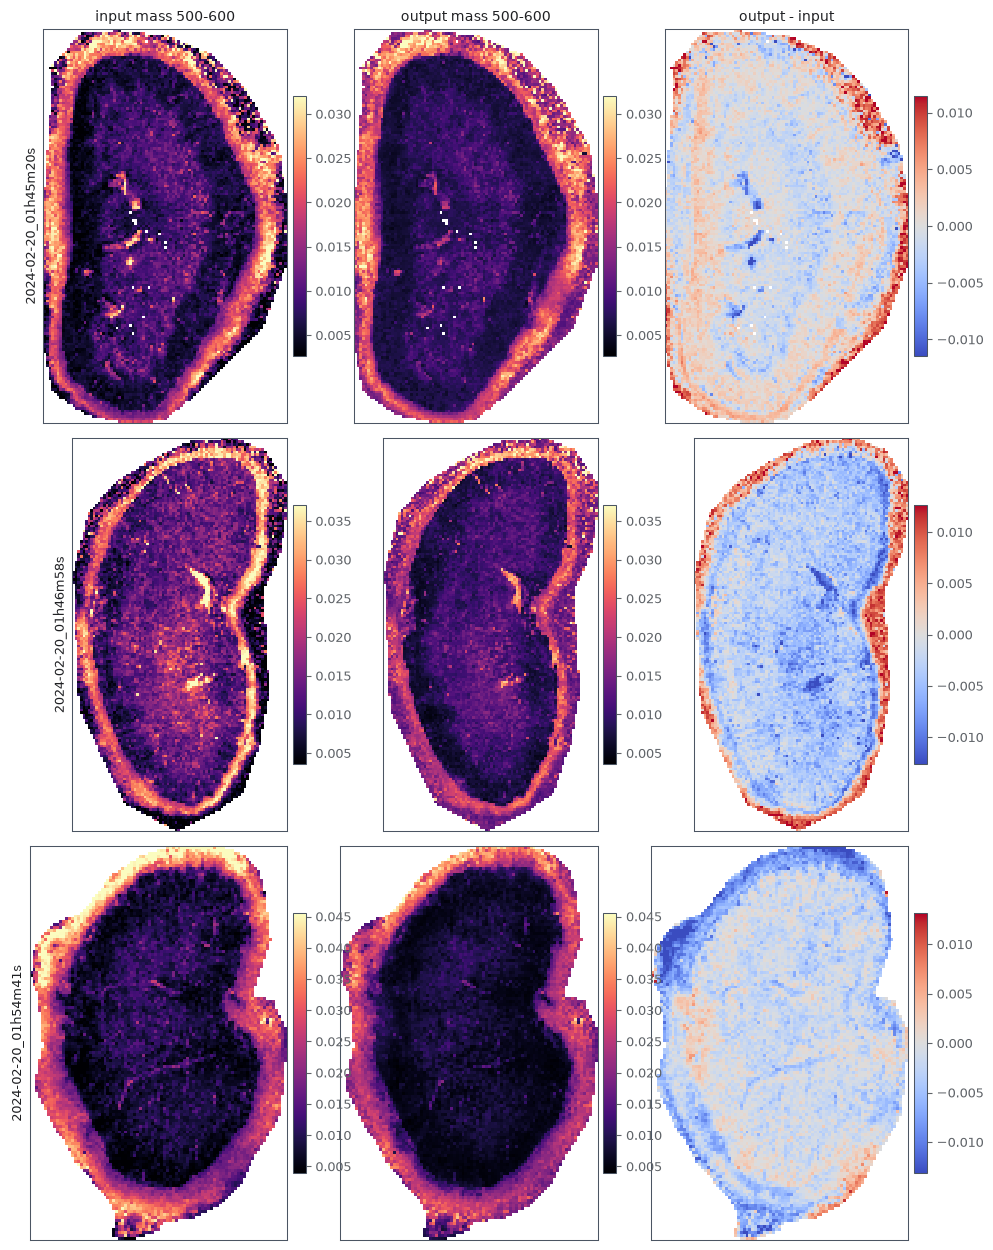

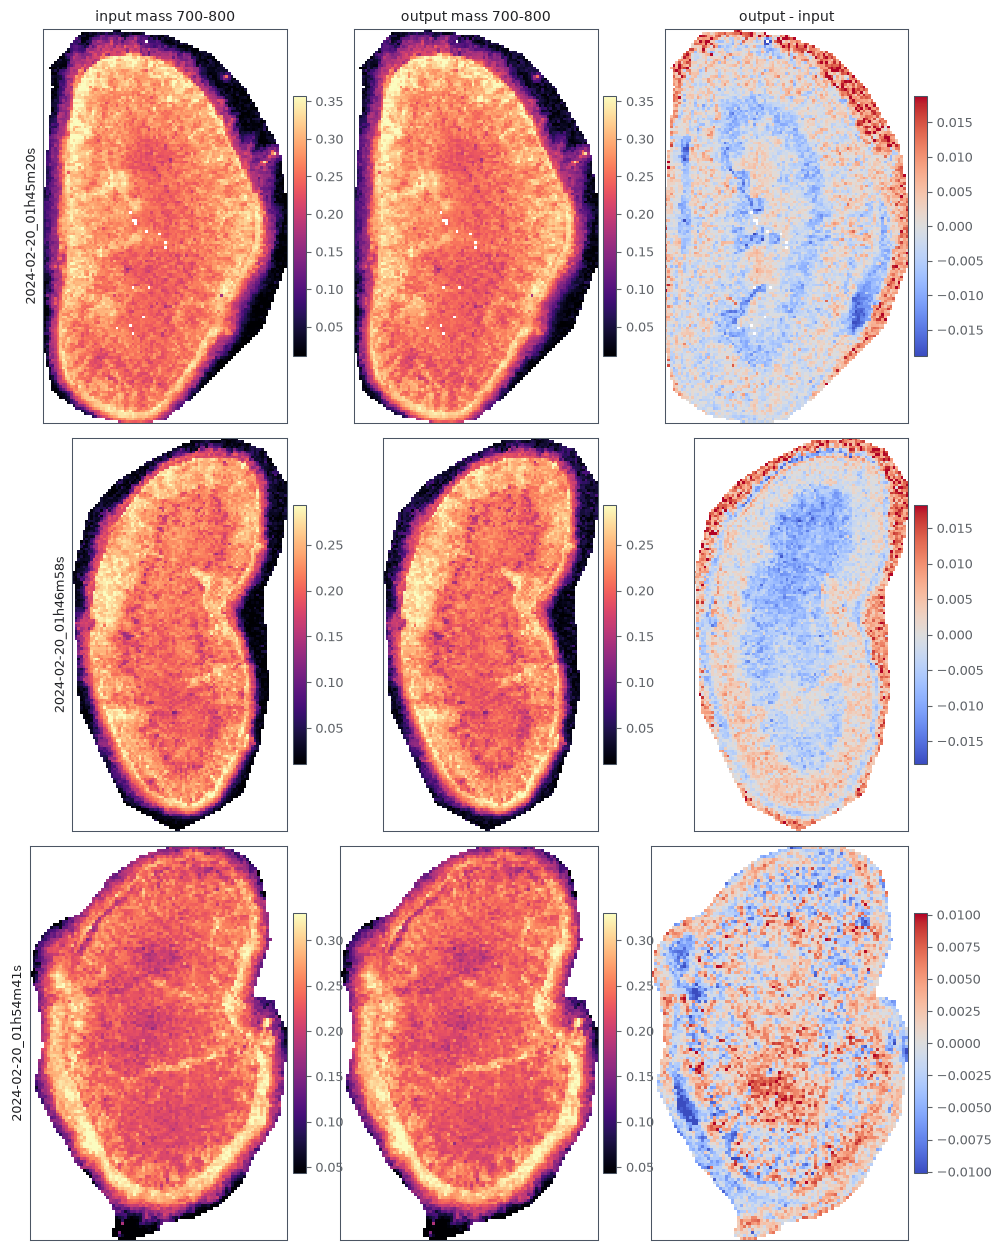

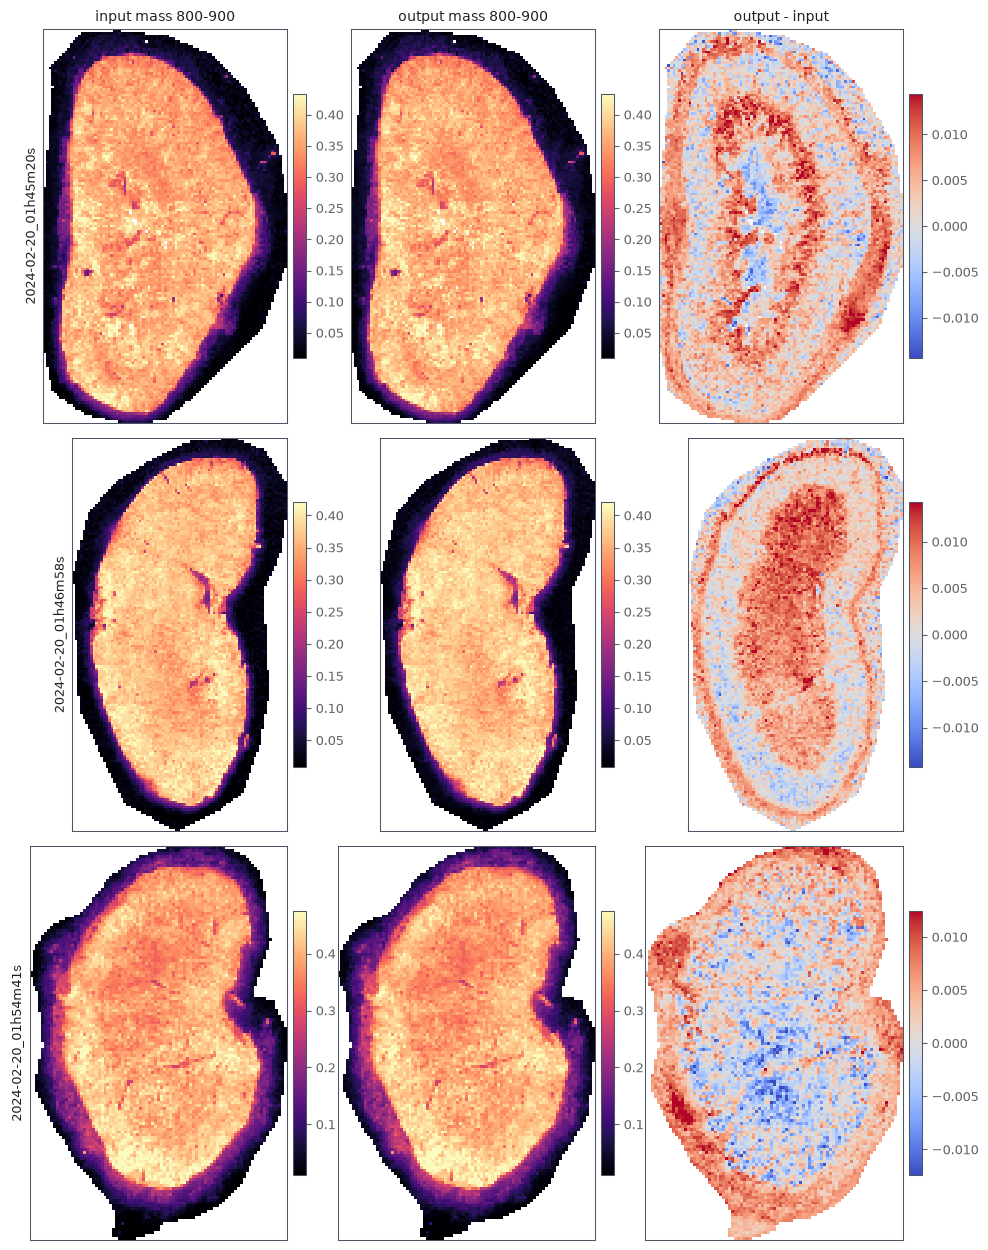

In [7]:
for window in SHOWN_WINDOWS:
    frame = maps.assign(input=maps[f'input_mass__{window}'], output=maps[f'output_mass__{window}'])
    frame['difference'] = frame.output - frame.input
    figure = figures.image_panels(frame, value_columns=['input', 'output', 'difference'], column_titles=[f'input mass {window}', f'output mass {window}', 'output - input'], datasets=DATASETS, shared_scale='row', diverging_columns=['difference'], theme=theme)
    plt.show()

### Remarks

- Input and output window-mass images are visually indistinguishable in every displayed window; the mean absolute difference is 0.003-0.005 of the pixel TIC.

### Notes

## Agreement of input and output window-mass images

### Methodology

#### Theoretical

Per image and window: Pearson and Spearman correlation between $M_W$ and $\hat M_W$ over the pixels (is the
spatial pattern kept) and the least-squares slope of $\hat M_W$ on $M_W$ (1 = the contrast between pixels is
kept, below 1 = the output image is flattened towards the image mean).

#### Implementation

`window_mass_relation` holds one row per model, image and displayed window.

#### Figure descriptions

Two panels: x = window, y = Pearson correlation (left) and slope (right); colour = held-out image, one point per
repetition, bar = mean. The table gives repetition means.

pearson                                                          slope                                          
dataset_id   2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s 2024-02-20_01h45m20s 2024-02-20_01h46m58s 2024-02-20_01h54m41s
window_label                                                                                                                              
200-300                     0.997                0.999                0.995                0.983                0.971                0.989
300-400                     0.997                0.998                0.998                0.978                0.989                0.980
400-500                     0.978                0.985                0.980                1.023                1.027                1.084
500-600                     0.911                0.841                0.978                0.854                0.657                0.785
700-800                     0.998                0.997                0.996                0.971                0.972                1.004
800-900                     0.999                1.000                1.000                1.007                1.010                0.987

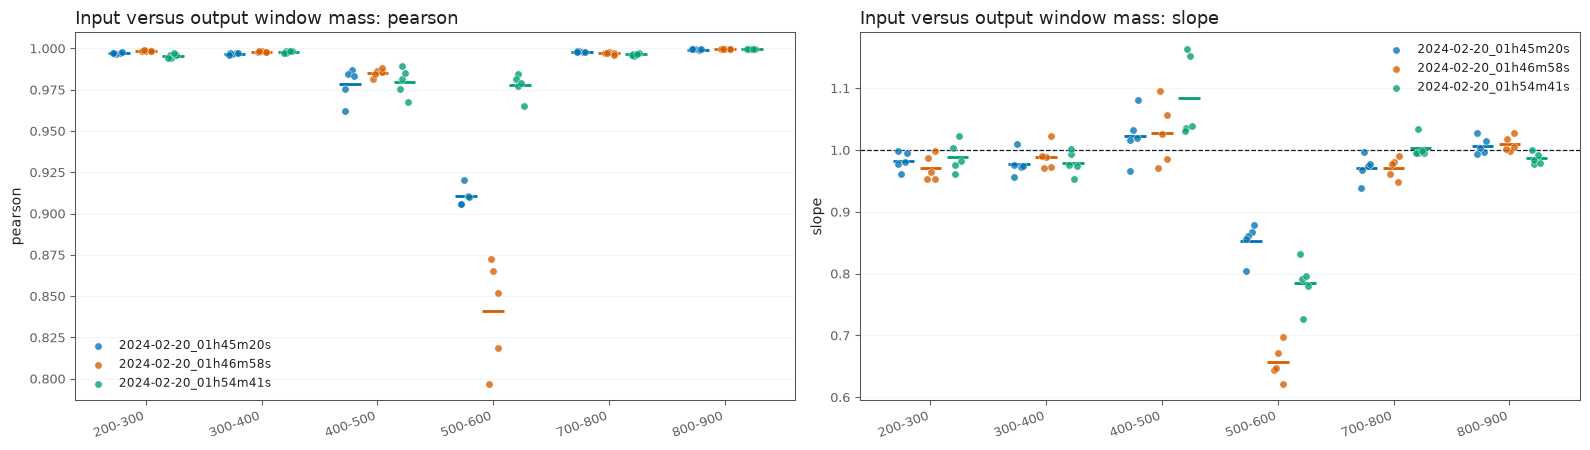

In [8]:
relation = table('window_mass_relation')
order = list(dict.fromkeys(relation.sort_values('window_lower').window_label))
image_colors = {dataset: theme.model_palette[position % len(theme.model_palette)] for position, dataset in enumerate(DATASETS)}
figure, axes = plt.subplots(1, 2, figsize=(16, 4.6), dpi=theme.figure_dpi)
for ax, value, reference in zip(axes, ['pearson', 'slope'], [None, 1.0]):
    figures.repetition_points(relation, value=value, group='window_label', hue='dataset_id', order=order, hue_order=DATASETS, colors=image_colors, ylabel=value, title=f'Input versus output window mass: {value}', reference=reference, ax=ax, theme=theme)
figure.tight_layout()
display(relation.pivot_table(index='window_label', columns='dataset_id', values=['pearson', 'slope']).loc[order].round(3))

### Remarks

- Pearson >= 0.96 and slope 0.95-1.04 in every window except 500-600 m/z, where the output image is flattened (Pearson 0.80-0.97, slope 0.64-0.86); the same holds for all repetitions (500-600: Pearson 0.80-0.98).

### Notes

## Spectra of the best, median and worst pixel of every image

### Methodology

#### Theoretical

Static counterparts of the interactive browser: for every image the pixels with the smallest, median and
largest $W_1$ of the representative model, in full and zoomed on the strongest peak and on the window with the
largest contribution.

#### Implementation

`browser_pixels` holds input and reconstruction of these pixels on the displayed bins; the window with the largest contribution is read from `pixel_maps`.

#### Figure descriptions

First figure: rows = held-out images, columns = best / median / worst pixel; x = m/z (gaps = windows not
displayed), grey = input, colour = reconstruction. Then one zoom figure per image (rows = best, median,
worst pixel; columns and residuals as in `part_1_03`).

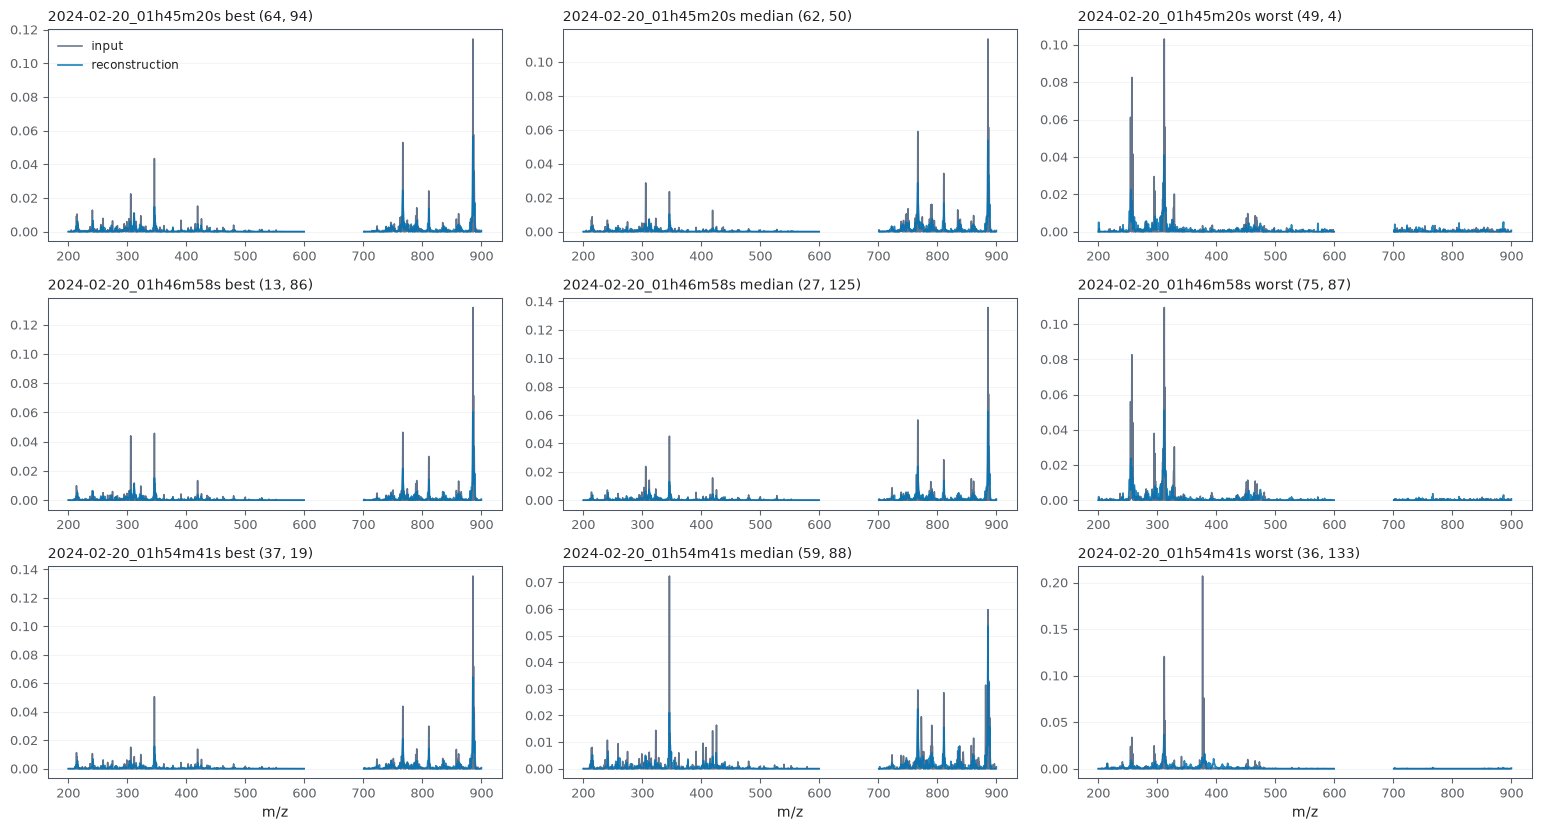

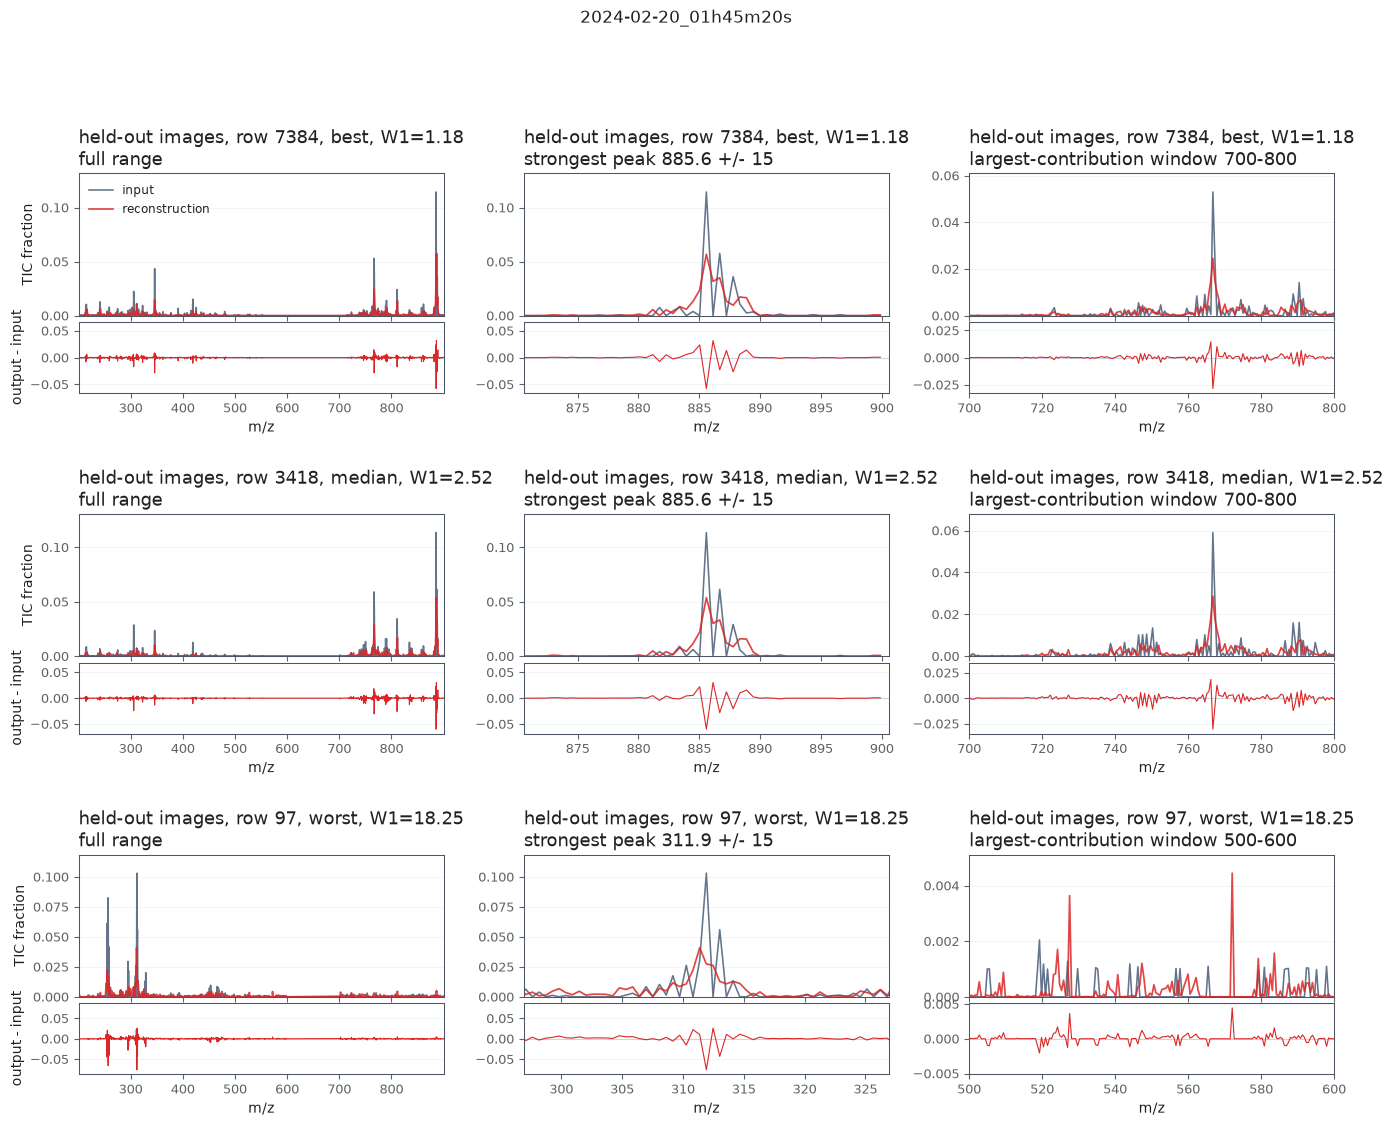

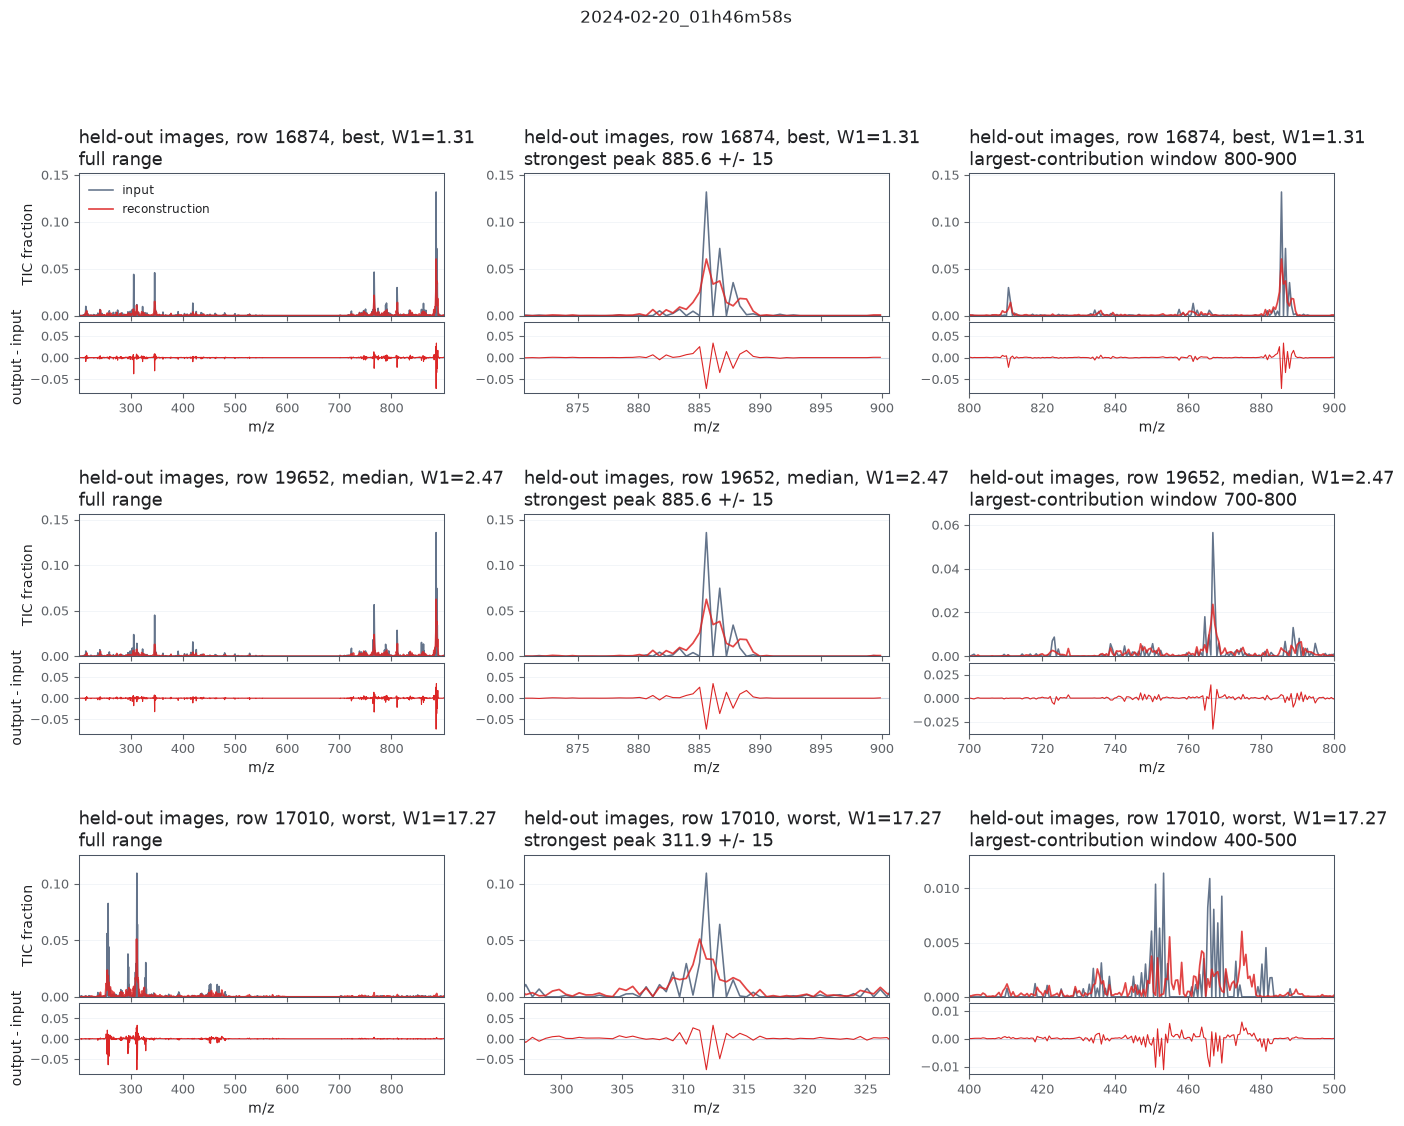

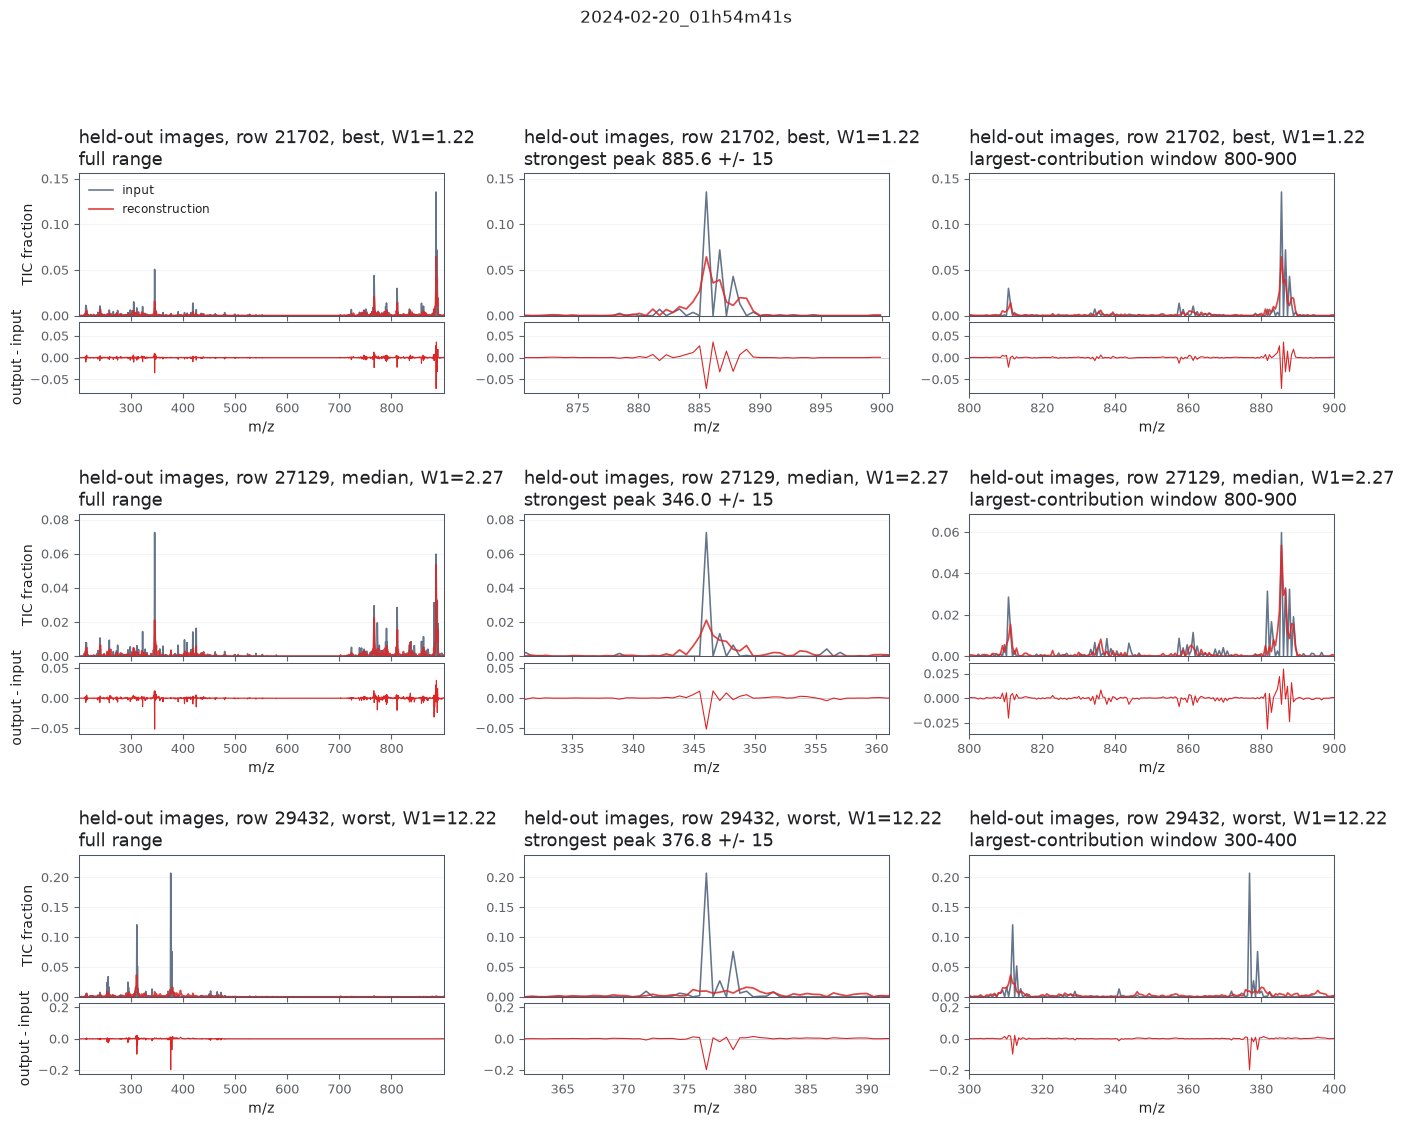

In [9]:
browser = table('browser_pixels')
figures.pixel_spectra(browser, datasets=DATASETS, theme=theme);
window_columns = [column for column in maps.columns if column.startswith('contribution__')]
zoom = browser.assign(population='heldout_image', case_kind=browser.pixel_kind)
by_row = maps.set_index('row')
for dataset in DATASETS:
    frame = zoom[zoom.dataset_id == dataset]
    keys = [('heldout_image', int(frame[frame.pixel_kind == kind].row.iloc[0])) for kind in ('best', 'median', 'worst')]
    worst = {}
    for key in keys:
        label = by_row.loc[key[1], window_columns].astype(float).idxmax().split('__')[1]
        lower, upper = (float(value) for value in label.split('-'))
        worst[key] = (label, lower, upper)
    figures.spectrum_zoom(frame, keys=keys, half_width=15.0, worst_windows=worst, theme=theme)
    plt.suptitle(dataset, y=1.02)
    plt.show()

### Remarks

- Best / median / worst pixel $W_1$: about 1.2 / 2.3-2.5 / 12-18; two of the three worst pixels lie at the top or bottom edge of their image (y = 4 and y = 133).

### Notes

## Interactive pixel browser

### Methodology

#### Theoretical

Browsing individual pixels connects the maps with the spectra: choose an image and a pixel position to see
its input, its reconstruction and its window contributions.

#### Implementation

The browser memory-maps the stored display arrays of the cache (paths recorded in the metadata of this
notebook's results); no model is loaded. Bins outside the displayed windows are not stored.

#### Figure descriptions

Left: map of $W_1$ with the selected pixel; middle: input (grey) and reconstruction (colour) of the pixel;
right: window contributions of the pixel (representative model). Interactive output is not saved.

In [10]:
display_input = np.load(metadata['display_input'], mmap_mode='r')
display_bins = np.load(metadata['display_bins'])
display_output = np.load(metadata['display_reconstruction'], mmap_mode='r')
bin_mz = browser.drop_duplicates('bin').set_index('bin').mz
mass_axis = np.full(int(display_bins.max()) + 1, np.nan)
mass_axis[bin_mz.index.to_numpy()] = bin_mz.to_numpy()
display(figures.pixel_browser(maps, map_column='masserstein', display_input=display_input, display_output=display_output, bins=display_bins, mass_axis=mass_axis, window_columns=[f'contribution__{window}' for window in SHOWN_WINDOWS], theme=theme))

### Remarks

### Notes

## Results / Summary

### LLM

- **Observed:** the Masserstein error of a new image is spatially structured (tissue border, low-intensity regions) and about 20 % of it varies between repetitions.
- **Observed:** the mass of every 100 Da window is reproduced pixel by pixel with its spatial pattern (Pearson >= 0.96, slope about 1), except 500-600 m/z, which carries little mass and is flattened.
- **Interpretation:** at the resolution of 100 Da windows the whole images are reconstructed correctly; the error sits inside the windows (peak shape, `part_1_03`) and shows up in single m/z channels (`part_1_05`).

### Person